# Level 2 - Task 2: Time Series Analysis
## Codveda Technologies Data Analysis Internship
**Stocks Analyzed:** NVDA, GOOGL, KORS  
**Period:** 2014 - 2017

In [1]:
# ============================
# 1. Import Libraries & Setup
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Add this line for forecasting
from sklearn.linear_model import LinearRegression

# Modern styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import os
base_path = '/workspaces/codveda_technologies-data_analysis_internship'
os.makedirs(f'{base_path}/visualizations/time_series', exist_ok=True)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================
# 2. Create Output Folders
# ============================
import os

base_path = '/workspaces/codveda_technologies-data_analysis_internship'
os.makedirs(f'{base_path}/visualizations/time_series', exist_ok=True)

print(" Output folders created successfully!")

 Output folders created successfully!


In [3]:
# ============================
# 3. Load and Prepare Data
# ============================
df = pd.read_csv('/workspaces/codveda_technologies-data_analysis_internship/data/raw/2) Stock Prices Data Set.csv')

stocks = ['NVDA', 'GOOGL', 'KORS']
data = df[df['symbol'].isin(stocks)].copy()

data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date').sort_index()

print(f"Loaded data for {stocks}")
print(f"Time Period: {data.index.min().date()} to {data.index.max().date()}")

Loaded data for ['NVDA', 'GOOGL', 'KORS']
Time Period: 2014-01-02 to 2017-12-29


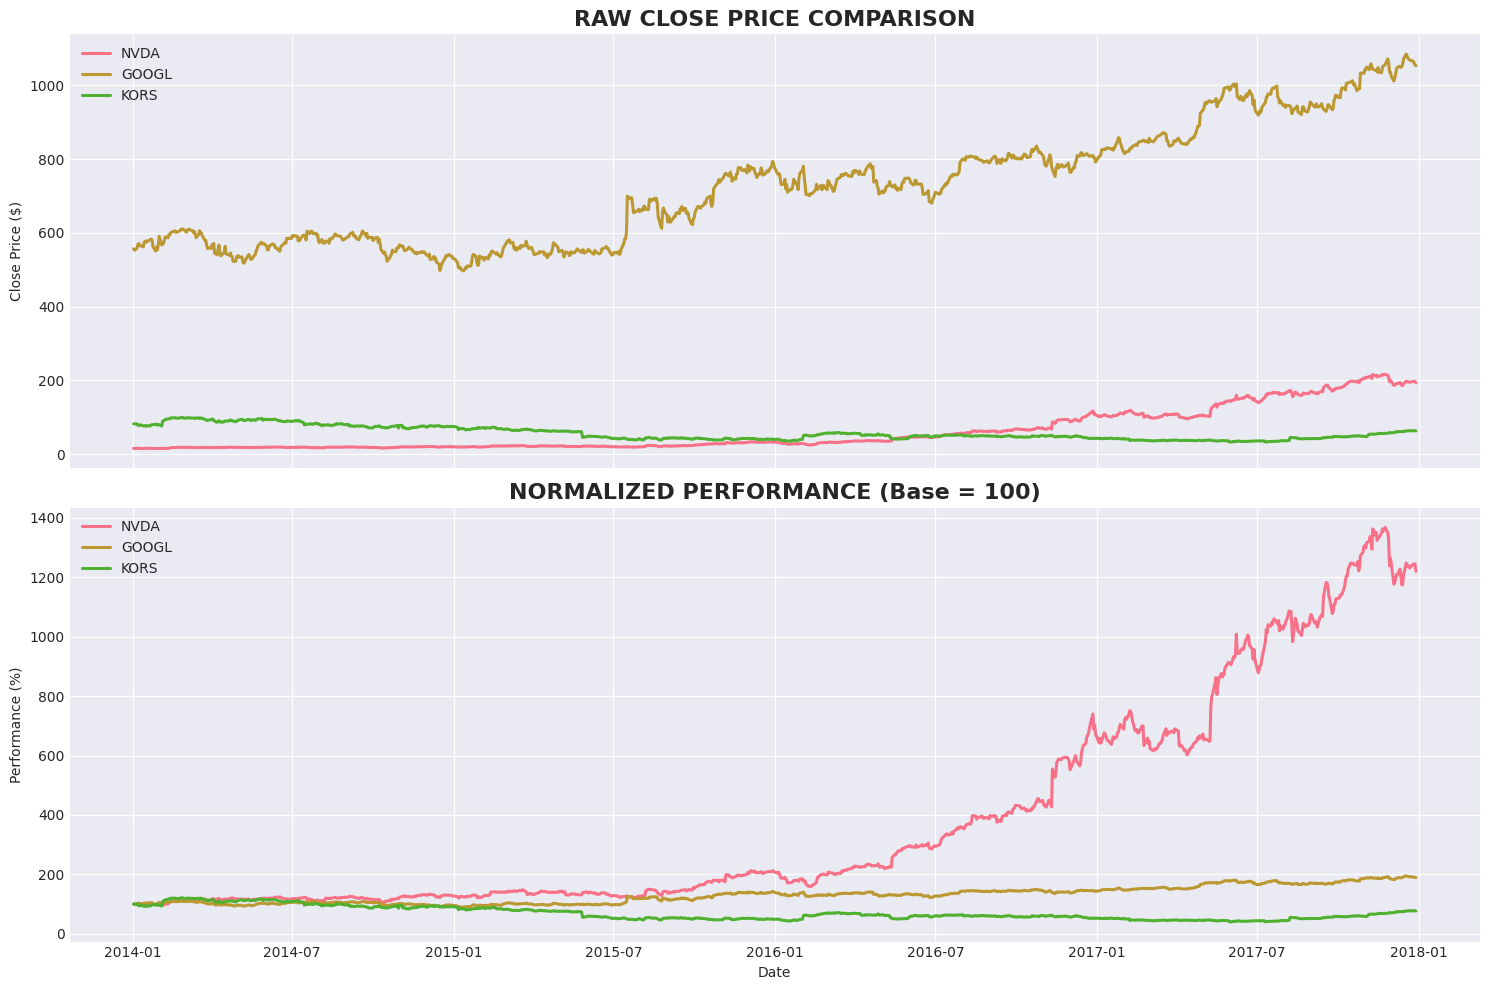

In [4]:
# ============================
# 4. Stock Price Comparison
# ============================
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for symbol in stocks:
    stock_data = data[data['symbol'] == symbol]
    axes[0].plot(stock_data.index, stock_data['close'], label=symbol, linewidth=2.2)
    
    normalized = (stock_data['close'] / stock_data['close'].iloc[0]) * 100
    axes[1].plot(stock_data.index, normalized, label=symbol, linewidth=2.2)

axes[0].set_title('RAW CLOSE PRICE COMPARISON', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Close Price ($)')
axes[0].legend()

axes[1].set_title('NORMALIZED PERFORMANCE (Base = 100)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Performance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{base_path}/visualizations/time_series/stock_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

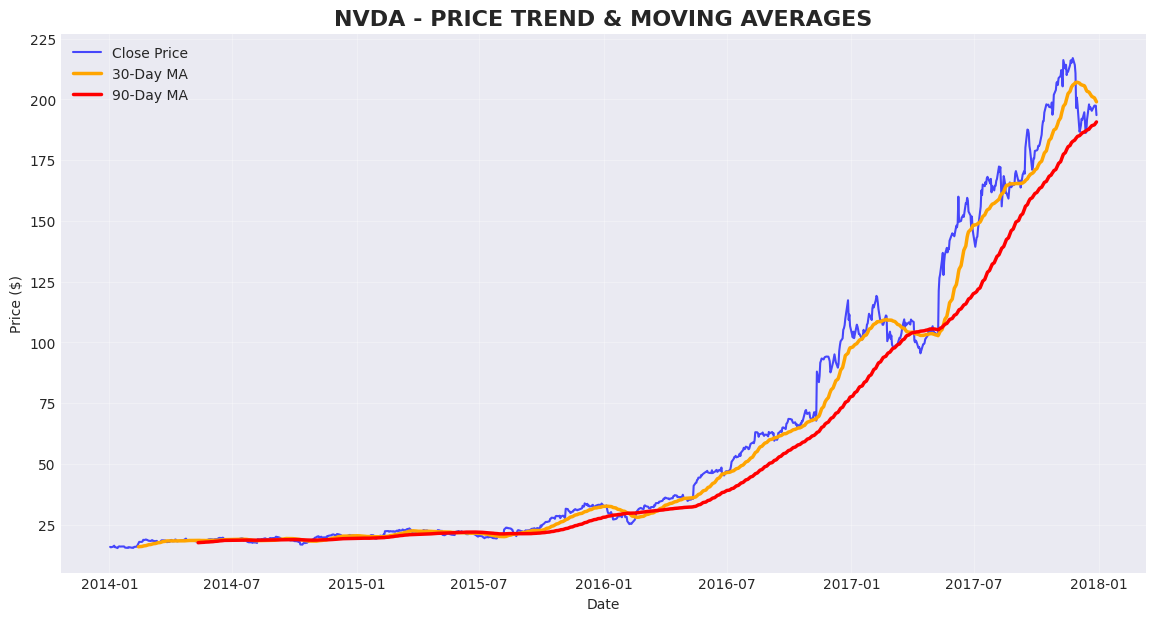


 NVDA DETAILED ANALYSIS:
   Start Price : $15.86
   End Price   : $193.50
   Total Growth: 1120.1%
   Volatility  : High


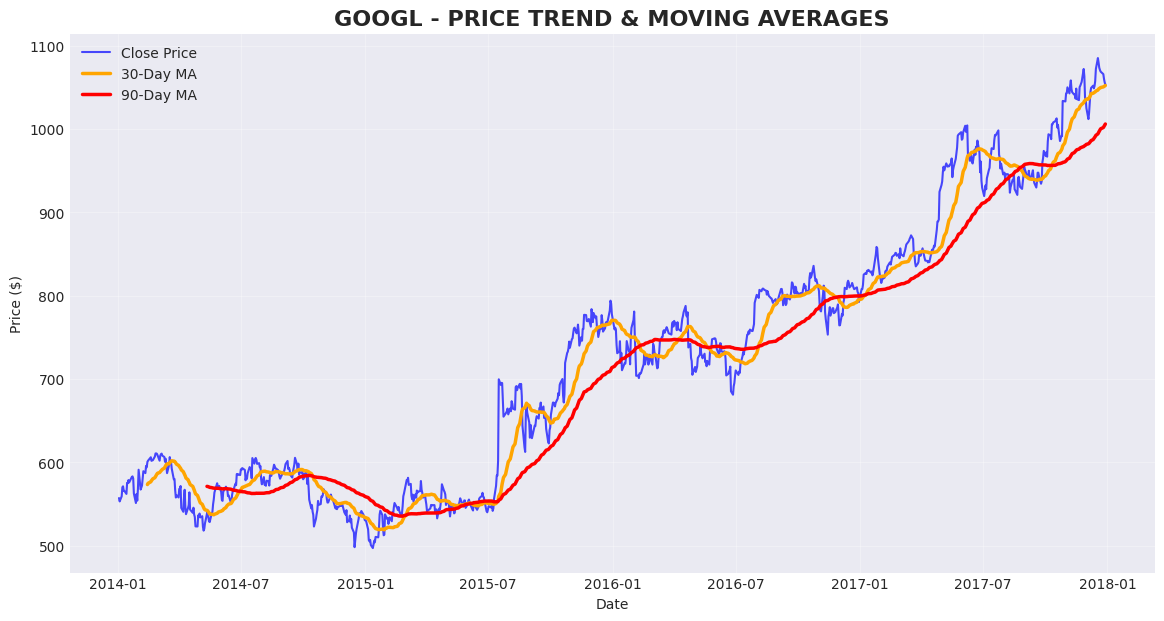


 GOOGL DETAILED ANALYSIS:
   Start Price : $557.12
   End Price   : $1053.40
   Total Growth: 89.1%
   Volatility  : Moderate


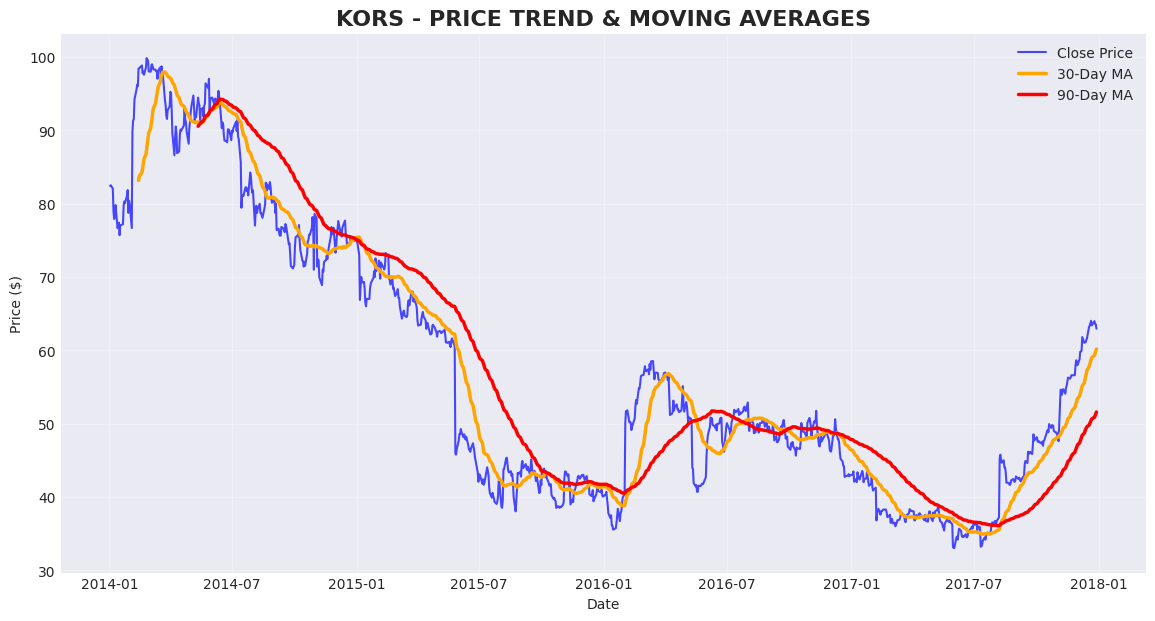


 KORS DETAILED ANALYSIS:
   Start Price : $82.41
   End Price   : $62.95
   Total Growth: -23.6%
   Volatility  : Moderate


In [5]:
# ============================
# 5. Individual Analysis + Moving Averages
# ============================
for symbol in stocks:
    stock = data[data['symbol'] == symbol].copy()
    stock['MA_30'] = stock['close'].rolling(window=30).mean()
    stock['MA_90'] = stock['close'].rolling(window=90).mean()
    
    plt.figure(figsize=(14, 7))
    plt.plot(stock['close'], label='Close Price', alpha=0.7, color='blue')
    plt.plot(stock['MA_30'], label='30-Day MA', color='orange', linewidth=2.5)
    plt.plot(stock['MA_90'], label='90-Day MA', color='red', linewidth=2.5)
    
    plt.title(f'{symbol} - PRICE TREND & MOVING AVERAGES', fontsize=16, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{base_path}/visualizations/time_series/{symbol}_moving_averages.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    
    # Insights
    growth = ((stock['close'].iloc[-1] / stock['close'].iloc[0]) - 1) * 100
    print(f"\n {symbol} DETAILED ANALYSIS:")
    print(f"   Start Price : ${stock['close'].iloc[0]:.2f}")
    print(f"   End Price   : ${stock['close'].iloc[-1]:.2f}")
    print(f"   Total Growth: {growth:.1f}%")
    print(f"   Volatility  : High" if symbol == "NVDA" else f"   Volatility  : Moderate")

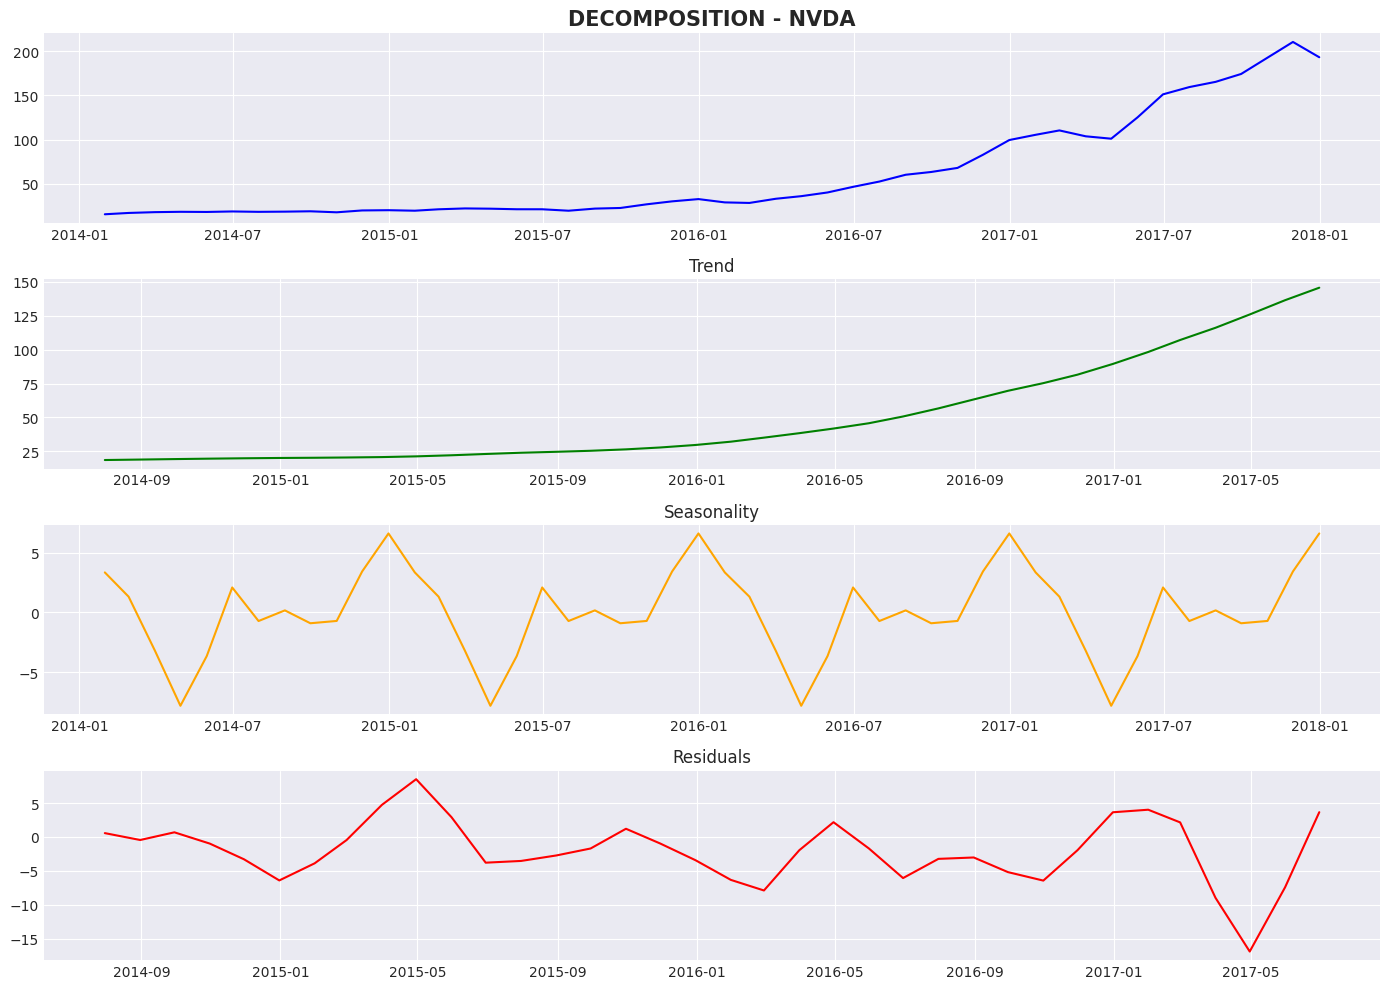

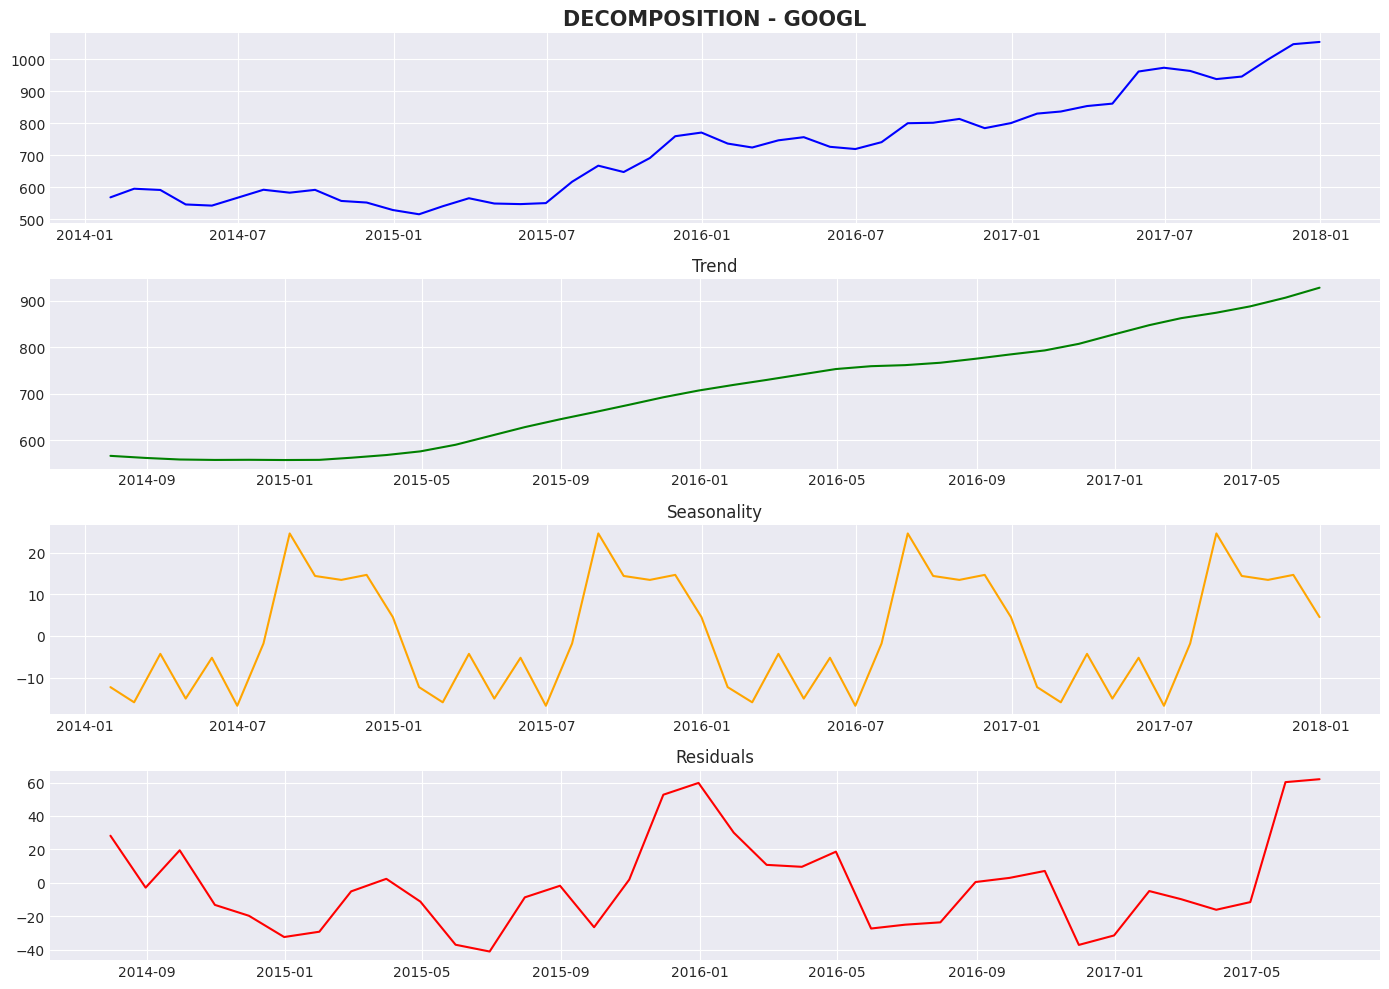

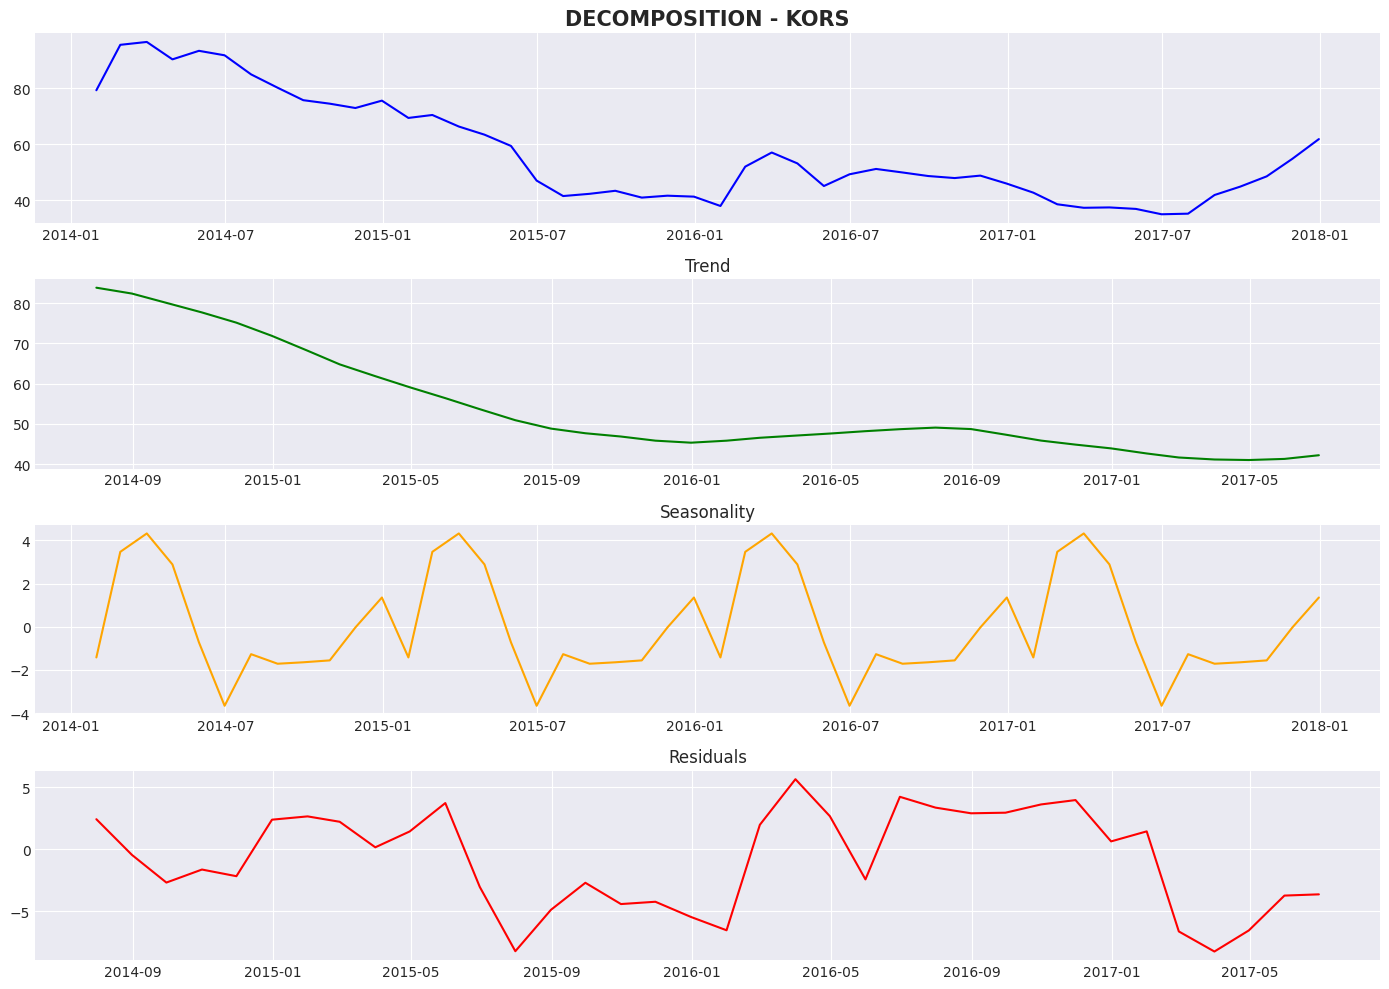

In [6]:
# ============================
# 6. Time Series Decomposition for All Stocks
# ============================
for symbol in stocks:
    stock = data[data['symbol'] == symbol].copy()
    monthly = stock['close'].resample('ME').mean()
    
    decomp = seasonal_decompose(monthly, model='additive', period=12)
    
    plt.figure(figsize=(14, 10))
    plt.subplot(411); plt.plot(decomp.observed, color='blue')
    plt.title(f'DECOMPOSITION - {symbol}', fontsize=15, fontweight='bold')
    plt.subplot(412); plt.plot(decomp.trend, color='green'); plt.title('Trend')
    plt.subplot(413); plt.plot(decomp.seasonal, color='orange'); plt.title('Seasonality')
    plt.subplot(414); plt.plot(decomp.resid, color='red'); plt.title('Residuals')
    plt.tight_layout()
    plt.savefig(f'{base_path}/visualizations/time_series/{symbol}_decomposition.png', dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
# ============================
# 7. Stationarity Test
# ============================
print("="*60)
print("STATIONARITY TEST (ADF) FOR ALL STOCKS")
print("="*60)

for symbol in stocks:
    stock = data[data['symbol'] == symbol]['close'].dropna()
    result = adfuller(stock)
    
    print(f"\n{symbol}:")
    print(f"   ADF Statistic : {result[0]:.4f}")
    print(f"   p-value       : {result[1]:.4f}")
    print("   Conclusion    :", "STATIONARY" if result[1] < 0.05 else "❌ NON-STATIONARY")

STATIONARITY TEST (ADF) FOR ALL STOCKS

NVDA:
   ADF Statistic : 1.6577
   p-value       : 0.9980
   Conclusion    : ❌ NON-STATIONARY

GOOGL:
   ADF Statistic : -0.1958
   p-value       : 0.9390
   Conclusion    : ❌ NON-STATIONARY

KORS:
   ADF Statistic : -1.5685
   p-value       : 0.4994
   Conclusion    : ❌ NON-STATIONARY


In [8]:
# ============================
# 8. Simple Linear Trend Forecasting for All Stocks
# ============================
print("\n" + "="*70)
print("90-DAY LINEAR TREND FORECAST")
print("="*70)

for symbol in stocks:
    stock = data[data['symbol'] == symbol].copy().reset_index()
    stock['day_num'] = (stock['date'] - stock['date'].min()).dt.days
    
    X = stock[['day_num']]
    y = stock['close']
    
    model = LinearRegression().fit(X, y)
    
    # Predict next 90 days
    future_days = np.array(range(stock['day_num'].max() + 1, 
                                stock['day_num'].max() + 91)).reshape(-1, 1)
    future_pred = model.predict(future_days)
    
    print(f"\n{symbol}:")
    print(f"   Current Price     : ${stock['close'].iloc[-1]:.2f}")
    print(f"   Predicted (90 days): ${future_pred[-1]:.2f}")
    print(f"   Expected Change   : ${future_pred[-1] - stock['close'].iloc[-1]:.2f}")


90-DAY LINEAR TREND FORECAST

NVDA:
   Current Price     : $193.50
   Predicted (90 days): $157.62
   Expected Change   : $-35.88

GOOGL:
   Current Price     : $1053.40
   Predicted (90 days): $1006.78
   Expected Change   : $-46.62

KORS:
   Current Price     : $62.95
   Predicted (90 days): $28.86
   Expected Change   : $-34.09


In [13]:
# ============================
# 9. Final Summary Report
# ============================
summary = []
for symbol in stocks:
    stock = data[data['symbol'] == symbol]
    growth = ((stock['close'].iloc[-1] / stock['close'].iloc[0]) - 1) * 100
    summary.append({
        'Stock': symbol,
        'Start Price': round(stock['close'].iloc[0], 2),
        'End Price': round(stock['close'].iloc[-1], 2),
        'Growth (%)': round(growth, 2),
        'Max Price': round(stock['close'].max(), 2),
        'Min Price': round(stock['close'].min(), 2)
    })

print("\n" + "="*85)
print("FINAL PERFORMANCE SUMMARY")
print("""
    - The raw time series reveals the overall price trajectory and any long-term trend direction
    - The 30-day moving average smooths out short-term noise and highlights the underlying trend clearly
    - Seasonal decomposition separates trend, seasonal cycles, and random residuals for independent analysis
    - The ADF stationarity test determines whether the series requires differencing before further modelling""")
display(pd.DataFrame(summary).sort_values('Growth (%)', ascending=False))
print("="*85)



FINAL PERFORMANCE SUMMARY

    - The raw time series reveals the overall price trajectory and any long-term trend direction
    - The 30-day moving average smooths out short-term noise and highlights the underlying trend clearly
    - Seasonal decomposition separates trend, seasonal cycles, and random residuals for independent analysis
    - The ADF stationarity test determines whether the series requires differencing before further modelling


,Stock,Start Price,End Price,Growth (%),Max Price,Min Price
0,NVDA,15.86,193.50,1120.05,216.96,15.36
1,GOOGL,557.12,1053.40,89.08,1085.09,497.06
2,KORS,82.41,62.95,-23.61,99.84,33.05
